We model the following ODE driven by the El Centro Earthquake:
$$
\ddot u(t) + 2\xi\omega_n\,\dot u(t) + \omega_n^{2}u(t)
        = -9.81\,a(t),
\qquad
u(0)=\dot u(0)=0,
$$
where $a(t)$ is the normalized ground-acceleration record, $\xi$ is the damping ratio, and $\omega_n$ is the natural frequency.


In the experiment, we take:
- $\xi = 0.02$
- $T_n = 5\,\mathrm{s}$
- $\omega_n = 2\pi/T_n$
 

## Imports

In [1]:
import os, sys, importlib

REPO = "/content/BSK_ODE"

print("Python executable:", sys.executable)
print("Repo exists:", os.path.exists(REPO))
print("Package exists:", os.path.exists(f"{REPO}/bsk_ode"))
print("Init exists:", os.path.exists(f"{REPO}/bsk_ode/__init__.py"))
print("Before:", [p for p in sys.path if "BSK_ODE" in p])

sys.path.insert(0, REPO)
importlib.invalidate_caches()

print("After:", [p for p in sys.path if "BSK_ODE" in p])

import bsk_ode
print("bsk_ode loaded from:", bsk_ode.__file__)

from bsk_ode import elcentro
print("elcentro loaded from:", elcentro.__file__)

Python executable: /usr/bin/python3
Repo exists: True
Package exists: True
Init exists: True
Before: []
After: ['/content/BSK_ODE']
Using device: cuda torch 2.11.0+cu128
Using device: cuda torch 2.11.0+cu128
Using device: cuda torch 2.11.0+cu128
bsk_ode loaded from: /content/BSK_ODE/bsk_ode/__init__.py
elcentro loaded from: /content/BSK_ODE/bsk_ode/elcentro.py


In [2]:
# Cell 1 - installs + clone
!pip install --quiet torch torchvision jax jaxlib keras_sig numpy matplotlib scipy pytorch-minimize
!git clone https://github.com/CharliePyle4/BSK_ODE.git /content/BSK_ODE 2>/dev/null || git -C /content/BSK_ODE pull

# Cell 2 - import
import sys
sys.path.insert(0, '/content/BSK_ODE')
from bsk_ode.elcentro import *
print("Using device:", device, "torch", torch.__version__)

remote: Enumerating objects: 11, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (3/3), done.
remote: Total 6 (delta 3), reused 6 (delta 3), pack-reused 0 (from 0)
Unpacking objects: 100% (6/6), 574.07 KiB | 7.76 MiB/s, done.
From https://github.com/CharliePyle4/BSK_ODE
   5a90661..5180254  main       -> origin/main
Updating 5a90661..5180254
Fast-forward
 bsk_ode/elcentro.py                 |  35 +-
 experiments/6.1_ElCentro_good.ipynb | 782 ++++--------------------------------
 2 files changed, 87 insertions(+), 730 deletions(-)
Using device: cuda torch 2.11.0+cu128


## Problem and Model Parameters

In [3]:
# Problem Setup
xi = .02
Tn = 5
omega = (2 * math.pi) / Tn

m = 1
c = 2 * xi * omega * m
k = omega ** 2
a = -9.81

signature_level = 12
reg_lambda = 1e-5
use_normalization = True



## Import Forcing and data

In [4]:
import os
os.chdir("/content/BSK_ODE")    # <- adjust if your clone path is different
F_t = pd.read_csv("Data/EQDATA.csv")        # from repo root
t_vals = torch.tensor(F_t["t"].values, dtype=torch.float64)
F_vals = a * torch.tensor(F_t["F"].values, dtype=torch.float64)
t_start = 0
t_end = 31.18
N = len(F_t)
dt = t_vals[1] - t_vals[0]
F_star = trapezoidal_cols(trapezoidal_cols(F_vals, dt), dt)


# Check Conditioning

In [5]:
diagnose_conditioning(t_vals, F_vals, m,c,k, 0, 0, signature_level, reg_lambda)


--- non-normalized ---


KeyboardInterrupt: 

## Run calibration

In [6]:
t_ref, U_ref = solve_linear_ivp(
    x_grid = t_vals,
    forcing_torch = F_vals,
    a = t_start, 
    b = t_end,
    ya = 0, 
    ypa = 0,
    k1 = m, 
    k2 = c,
    k3 = k
    )

U_hat, F_hat, _ = solve_signature_kernel_calibration(
    x=t_vals,        # time grid
    f=F_vals,        # raw forcing (a_g * acceleration)
    k1=m,            # mass
    k2=c,            # damping
    k3=k,            # stiffness
    ua=0.0,          # u(0)
    upa=0.0,         # u'(0)
    depth=signature_level,
    normalize=use_normalization,
    reg = reg_lambda
)



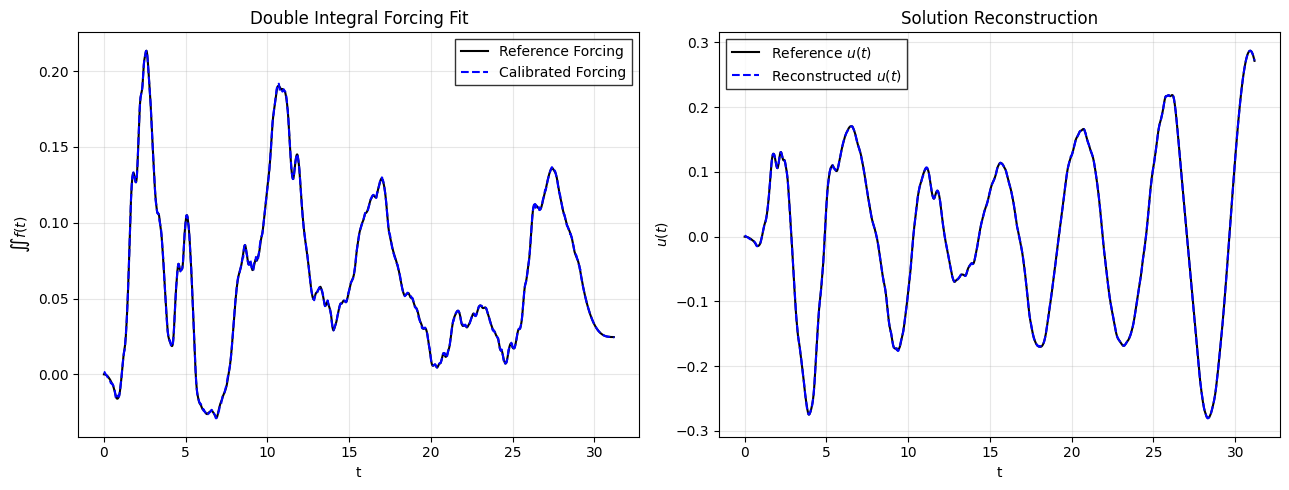


Model Error Summary
Quantity                   Absolute MSE       Relative MSE     Relative MSE (%)
--------------------------------------------------------------------------------
Forcing F*                 2.759573e-07       3.979981e-05              0.0040%
Solution u(t)              3.205158e-07       1.871363e-05              0.0019%


In [7]:
plot_calibration(t_vals, F_star, F_hat, U_ref, U_hat)
print_errors_calibration(F_hat,F_star,U_hat,U_ref)

# Testing Parameters

In [ ]:
TRAIN_FRAC = 0.5  # fraction of grid points used for training
holder_value = .2
reg_lambda = 1e-5

sig_depth_predict = 4
retrain_iters_predict = 5

sig_depth_rolling = 6
retrain_iters_rolling = 5

use_normalization = False



#Train / Test Split
N_train = int(N * TRAIN_FRAC)
N_test  = N - N_train

# Training slice: first N_train points (contiguous, causal split)
t_train  = t_vals[:N_train]
t_test   = t_vals[N_train:]
f_train  = F_vals[:N_train]     # raw forcing, not F_star
f_test   = F_vals[N_train:]


print(f"Total grid points : {N}")
print(f"Train points      : {N_train}  (x in [{float(t_train[0]):.3f}, {float(t_train[-1]):.3f}])")
print(f"Test  points      : {N_test}   (x in [{float(t_test[0]):.3f},  {float(t_test[-1]):.3f}])")

Total grid points : 1560
Train points      : 780  (x in [0.000, 15.580])
Test  points      : 780   (x in [15.600,  31.180])


## Prediction and retrain

In [9]:
import time

# ---- prediction with periodic retraining ----
if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full, f_pred_full = solve_signature_kernel_predict_retrain(
    t_train=t_train,
    t_test=t_test,
    f_train=f_train,
    f_test=f_test,
    k1=m,
    k2=c,
    k3=k,
    ua=0.0,
    upa=0.0,
    depth=sig_depth_predict,
    normalize=use_normalization,
    reg=reg_lambda,
    retrain_every=retrain_iters_predict
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for direct prediction and retrain method: {elapsed:.3f} seconds")

# ---- prediction with periodic retraining and t lift----
if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full_tlift, f_pred_full_tlift = solve_signature_kernel_predict_retrain(
    t_train=t_train,
    t_test=t_test,
    f_train=f_train,
    f_test=f_test,
    k1=m,
    k2=c,
    k3=k,
    ua=0.0,
    upa=0.0,
    depth=sig_depth_predict,
    normalize=use_normalization,
    reg=reg_lambda,
    retrain_every=retrain_iters_predict,
    use_tlift=True,
    holder_value=holder_value
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for direct prediction and retrain method, tlift: {elapsed:.3f} seconds")



final forcing loss (train+test, last beta): 7.383e+02
time for direct prediction and retrain method: 18.677 seconds
final forcing loss (train+test, last beta): 2.123e+02
time for direct prediction and retrain method, tlift: 31.265 seconds


# Evaluate

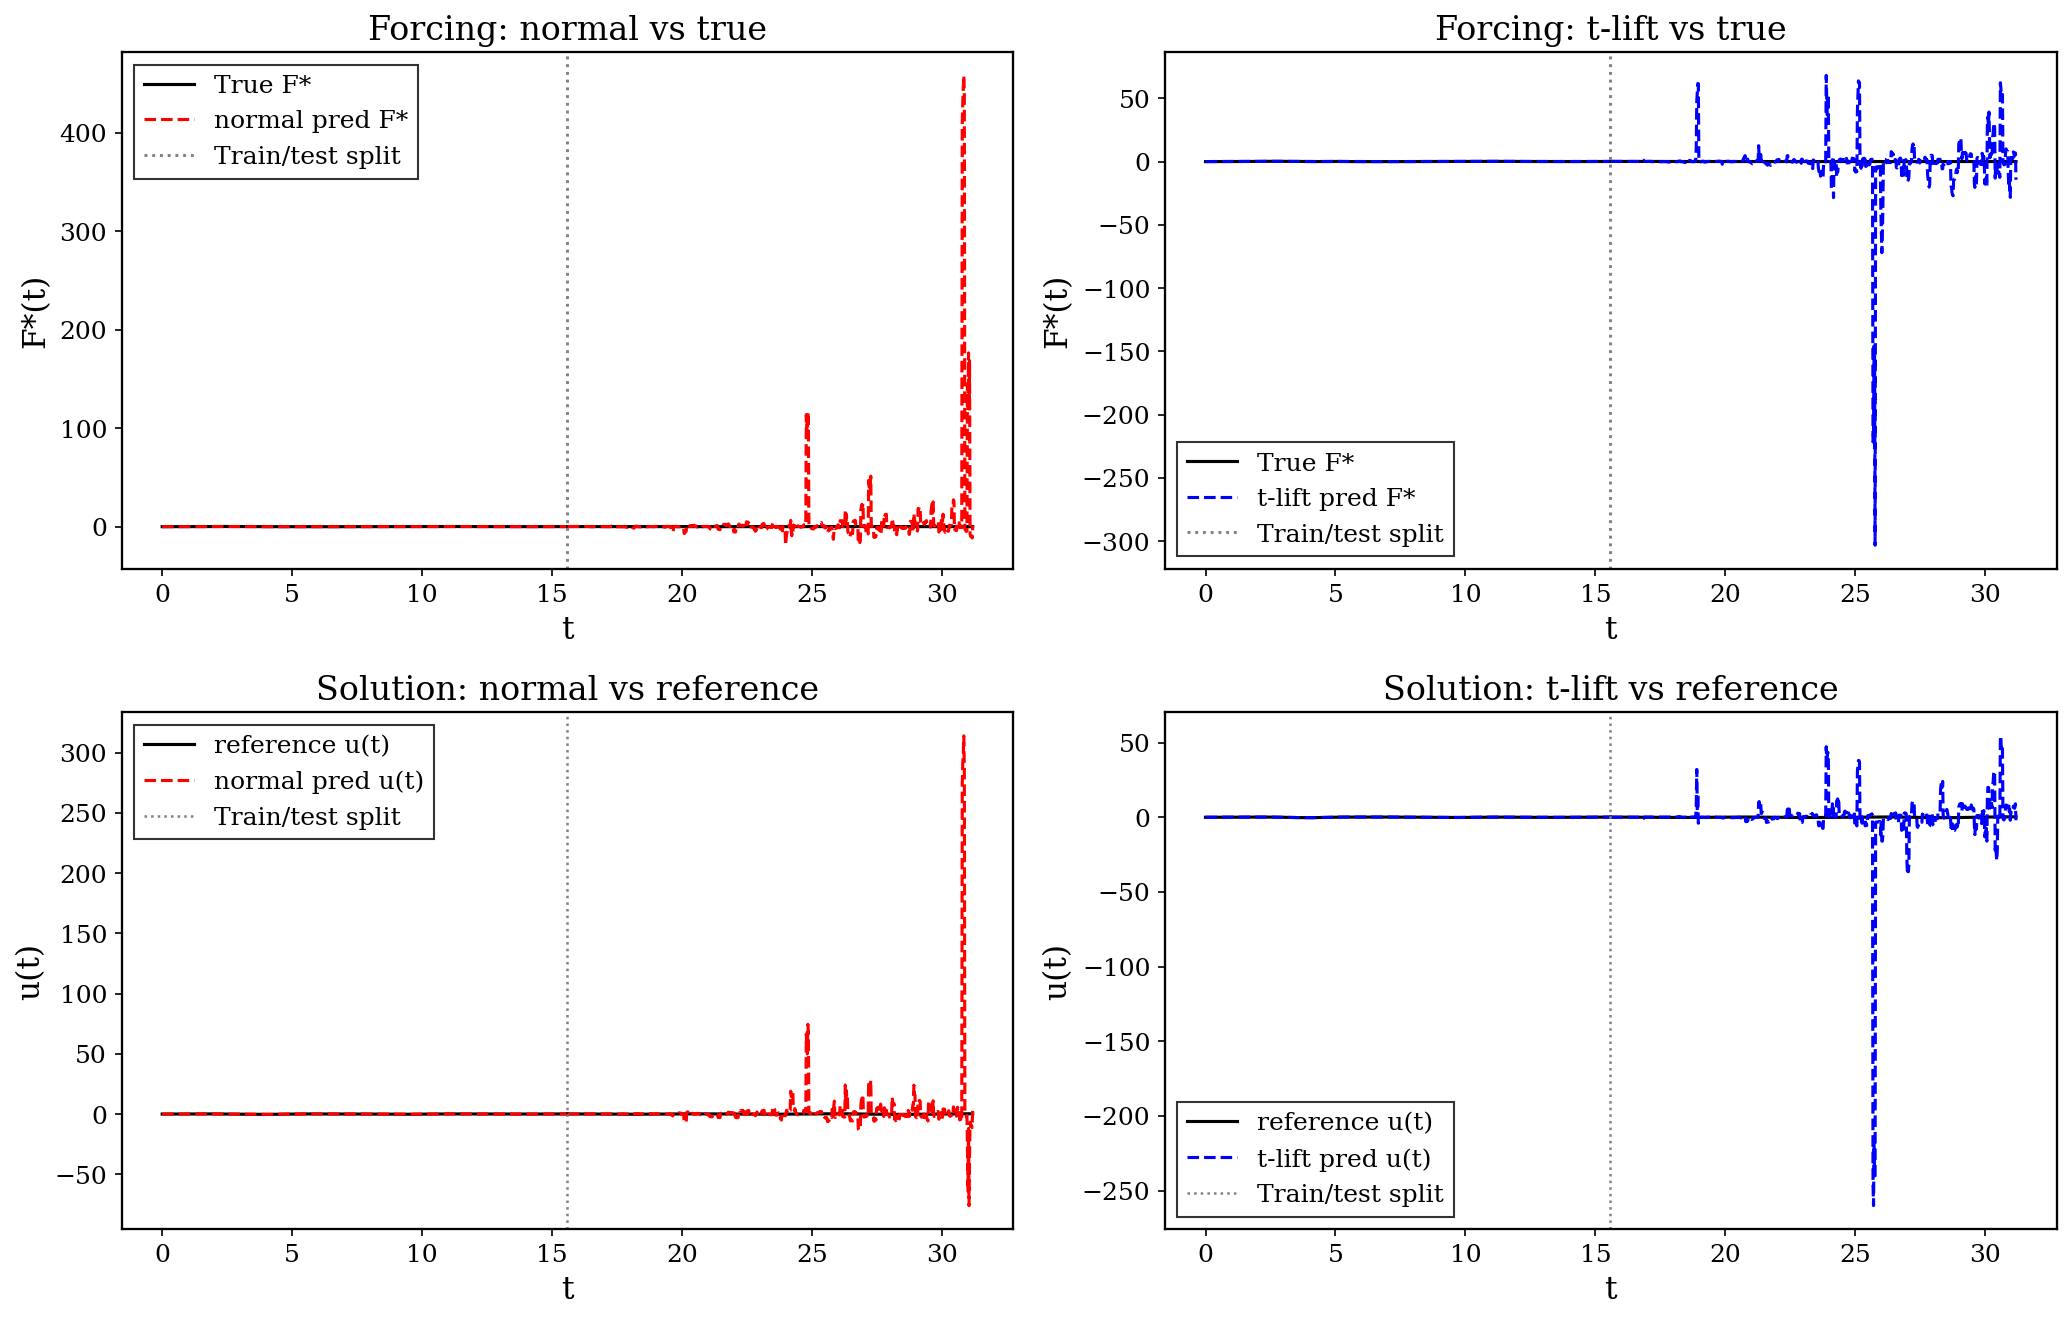


                                   Normal           t-lift  % Improvement
------------------------------------------------------------------------
Training forcing               8.8533e-05       2.9171e-05         67.05%
Training solution              2.7032e-05       1.3600e-05         49.69%
------------------------------------------------------------------------
Testing forcing                2.9434e+05       8.4987e+04         71.13%
Testing solution               2.7039e+04       1.9599e+04         27.52%
------------------------------------------------------------------------
Train+Test forcing             1.0634e+05       3.0706e+04         71.13%
Train+Test solution            1.7803e+04       1.2905e+04         27.52%


In [10]:
# 2x2 plots
plot_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full, f_pred_full,
    u_pred_full_tlift, f_pred_full_tlift,
    U_ref, F_star
)

# Relative MSE table
print_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full, f_pred_full,
    u_pred_full_tlift, f_pred_full_tlift,
    U_ref, F_star
)

## Rolling Retrain

In [11]:
## Rolling Retrain
import time

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full_rolling, f_pred_full_rolling = solve_signature_kernel_rolling_retrain(
    t_train=t_train, t_test=t_test,
    f_train=f_train, f_test=f_test,
    k1=m, k2=c, k3=k,
    ua=0.0, upa=0.0,
    depth=sig_depth_rolling, normalize=use_normalization,
    reg=reg_lambda, retrain_every=retrain_iters_rolling,
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for rolling prediction and retrain method: {elapsed:.3f} seconds")

if torch.cuda.is_available():
    torch.cuda.synchronize()
start_time = time.perf_counter()

u_pred_full_tlift_rolling, f_pred_full_tlift_rolling = solve_signature_kernel_rolling_retrain(
    t_train=t_train, t_test=t_test,
    f_train=f_train, f_test=f_test,
    k1=m, k2=c, k3=k,
    ua=0.0, upa=0.0,
    depth=sig_depth_rolling, normalize=use_normalization,
    reg=reg_lambda, retrain_every=retrain_iters_rolling,
    use_tlift=True,
    holder_value=holder_value
)

if torch.cuda.is_available():
    torch.cuda.synchronize()
elapsed = time.perf_counter() - start_time
print(f"time for rolling prediction and retrain method, tlift: {elapsed:.3f} seconds")


final forcing loss (train+test, rolling): 1.200e+03
time for rolling prediction and retrain method: 10.195 seconds
final forcing loss (train+test, rolling): 8.355e+03
time for rolling prediction and retrain method, tlift: 13.203 seconds


# Results

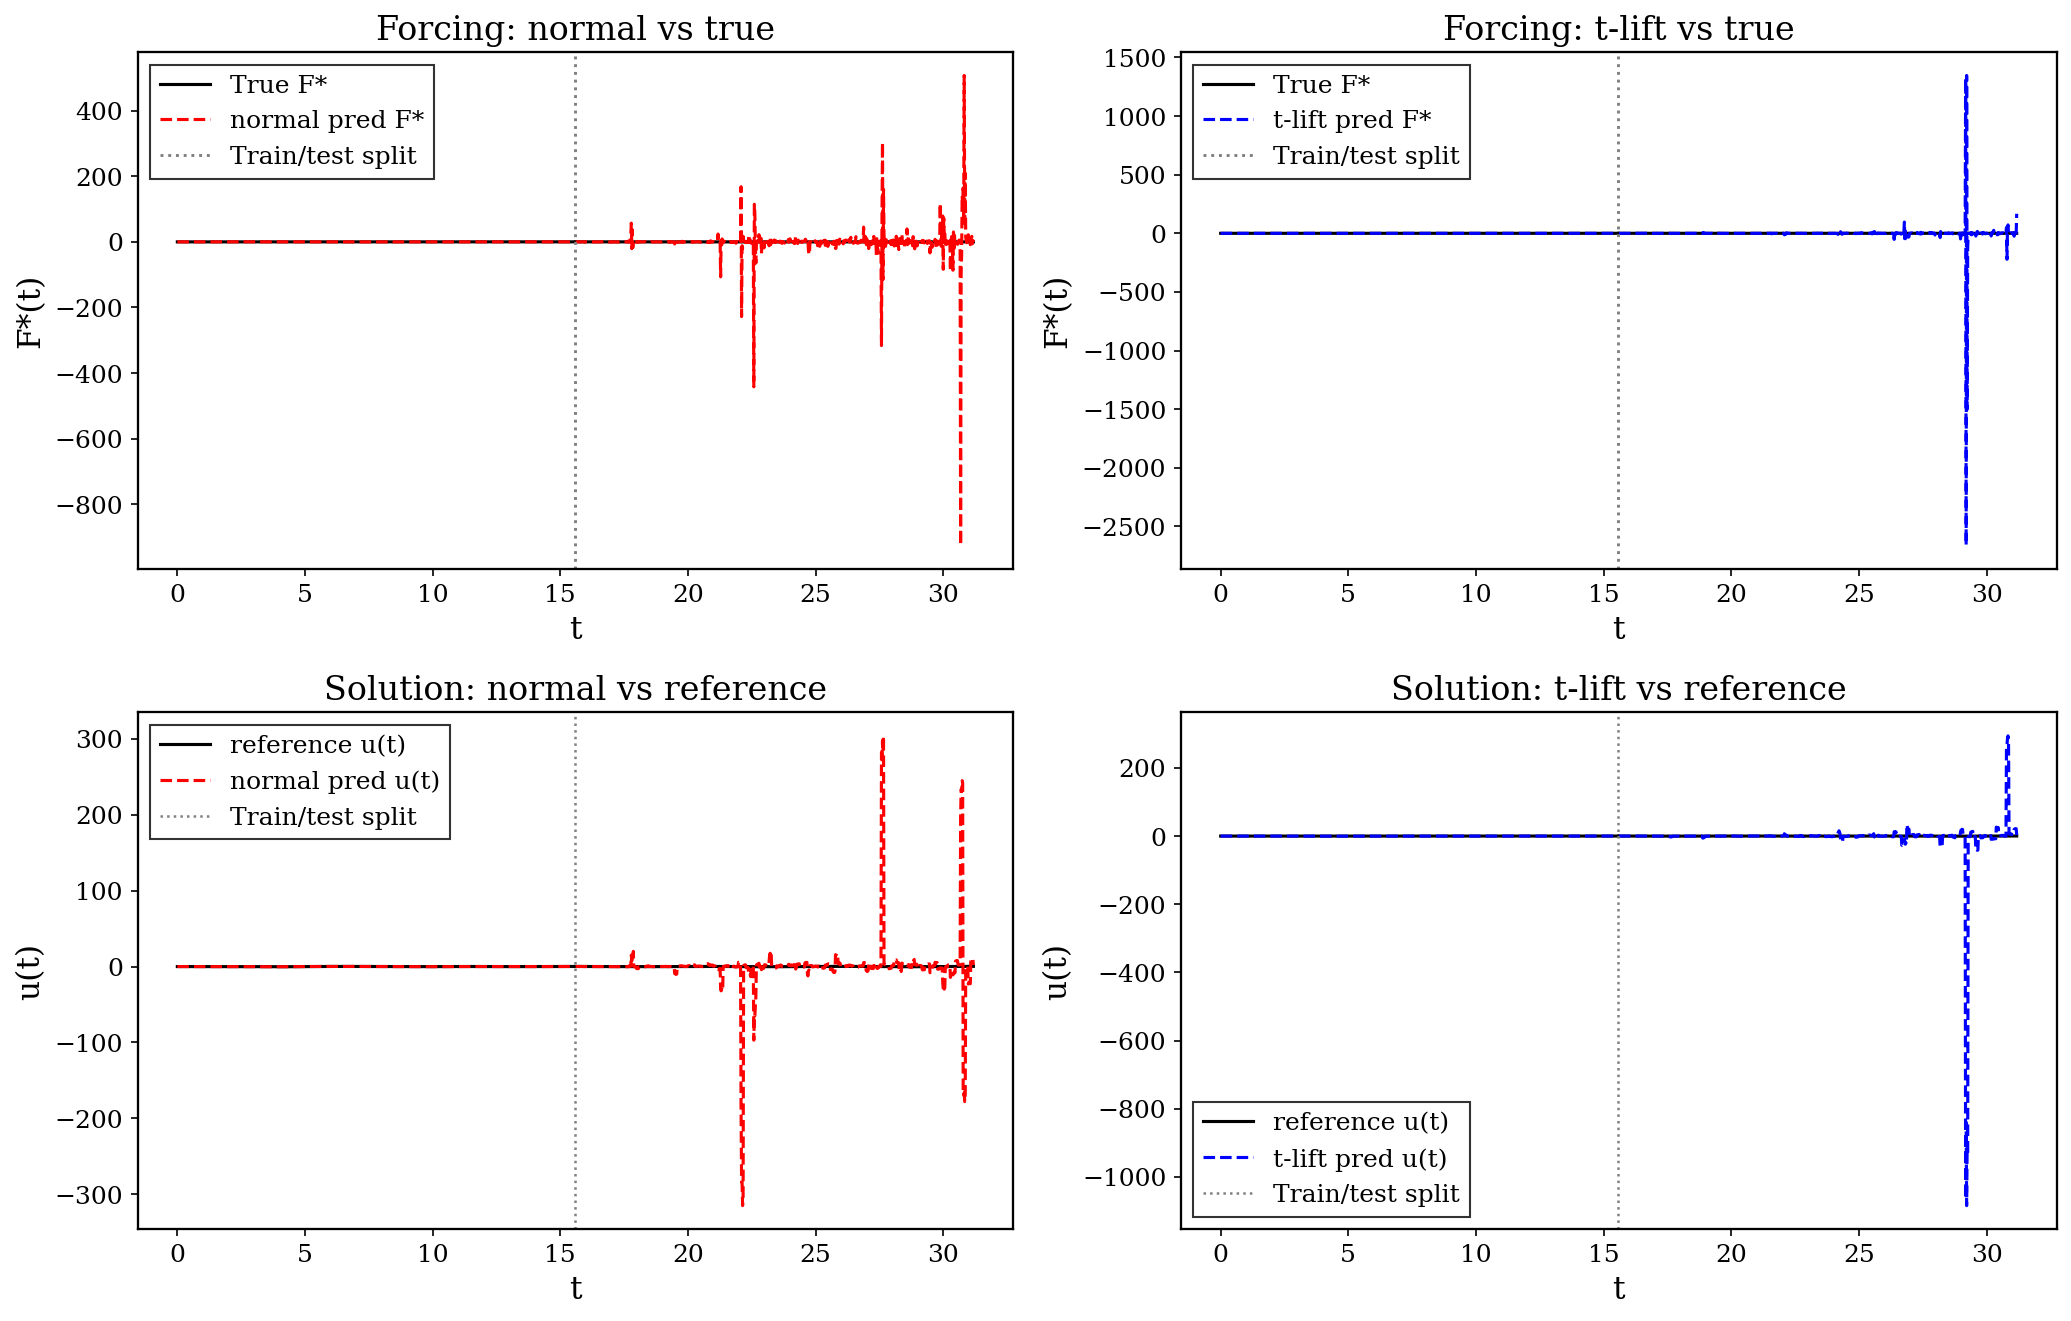


                                   Normal           t-lift  % Improvement
------------------------------------------------------------------------
Training forcing               6.6633e-03       6.9717e-04         89.54%
Training solution              7.8283e-03       6.4587e-04         91.75%
------------------------------------------------------------------------
Testing forcing                4.7884e+05       3.3350e+06       -596.49%
Testing solution               7.1245e+04       2.9135e+05       -308.94%
------------------------------------------------------------------------
Train+Test forcing             1.7300e+05       1.2049e+06       -596.49%
Train+Test solution            4.6910e+04       1.9183e+05       -308.94%


In [12]:
plot_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full_rolling, f_pred_full_rolling,
    u_pred_full_tlift_rolling, f_pred_full_tlift_rolling,
    U_ref, F_star
)
print_normal_vs_tlift(
    t_vals, TRAIN_FRAC,
    u_pred_full_rolling, f_pred_full_rolling,
    u_pred_full_tlift_rolling, f_pred_full_tlift_rolling,
    U_ref, F_star
)

# Compare

Method                              Split     Forcing Rel MSE   Solution Rel MSE
--------------------------------------------------------------------------------
Predict-Retrain (normal)            Train          8.8533e-05         2.7032e-05
                                    Test           2.9434e+05         2.7039e+04
                                    All            1.0634e+05         1.7803e+04
--------------------------------------------------------------------------------
Predict-Retrain (t-lift)            Train          2.9171e-05         1.3600e-05
                                    Test           8.4987e+04         1.9599e+04
                                    All            3.0706e+04         1.2905e+04
--------------------------------------------------------------------------------
Rolling-Retrain (normal)            Train          6.6633e-03         7.8283e-03
                                    Test           4.7884e+05         7.1245e+04
                            

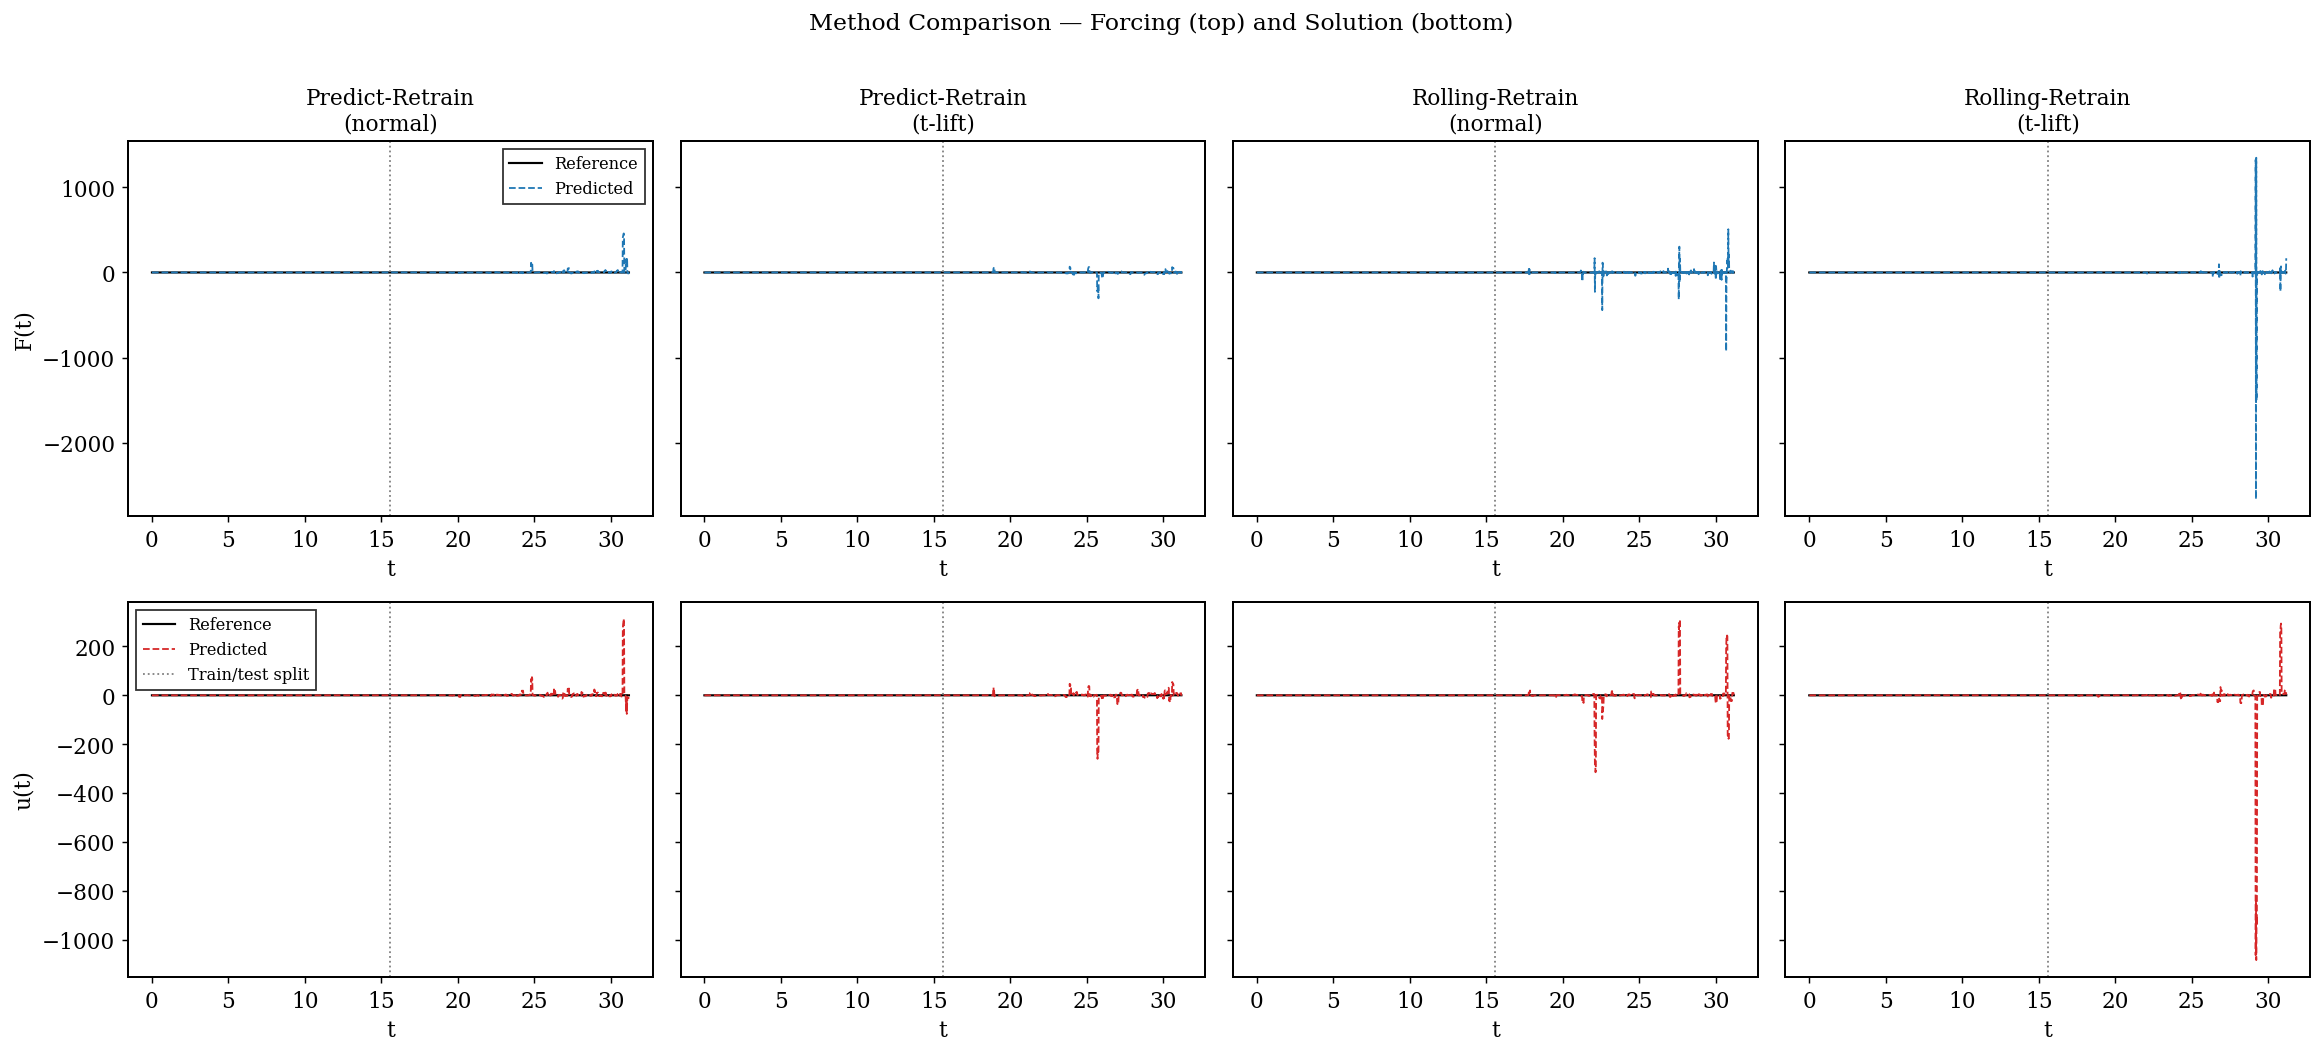

In [13]:
# --- Call both ---
print_method_comparison(
    t_vals, TRAIN_FRAC,
    f_pred_full, u_pred_full,
    f_pred_full_tlift, u_pred_full_tlift,
    f_pred_full_rolling, u_pred_full_rolling,
    f_pred_full_tlift_rolling, u_pred_full_tlift_rolling,
    F_star, U_ref
)

plot_method_comparison(
    t_vals, TRAIN_FRAC,
    f_pred_full, u_pred_full,
    f_pred_full_tlift, u_pred_full_tlift,
    f_pred_full_rolling, u_pred_full_rolling,
    f_pred_full_tlift_rolling, u_pred_full_tlift_rolling,
    F_star, U_ref
)